<a href="https://colab.research.google.com/github/sofol-bit/LinSofoNEUR265/blob/main/final/FinalAPOE4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
#import modules

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skewtest
from scipy.stats import mannwhitneyu
from scipy.stats import spearmanr

In [19]:
#import data

APOE4STATUS = pd.read_csv('https://raw.githubusercontent.com/sofol-bit/LinSofoNEUR265/refs/heads/main/final/%20APOE4%20-%20AT8%20-%20Iba1%20.csv')

In [20]:
#check data

print(APOE4STATUS)

   APOE4   AT8  Iba1
0      N  1222  8152
1      N     2  5733
2      N  1561  8824
3      Y   118  1119
4      N   100   448
..   ...   ...   ...
79     N   706  5182
80     N   839  5887
81     Y   175  6505
82     N  1723  5874
83     N     6  3622

[84 rows x 3 columns]


In [21]:
#split data into APOE4 pos and neg

yes = APOE4STATUS[APOE4STATUS["APOE4"] == "Y"]
no = APOE4STATUS[APOE4STATUS["APOE4"] == "N"]

AT8 skew test: SkewtestResult(statistic=np.float64(4.966547926273179), pvalue=np.float64(6.815521551418227e-07))
Iba1 skew test: SkewtestResult(statistic=np.float64(4.068250488493177), pvalue=np.float64(4.7367446120348714e-05))


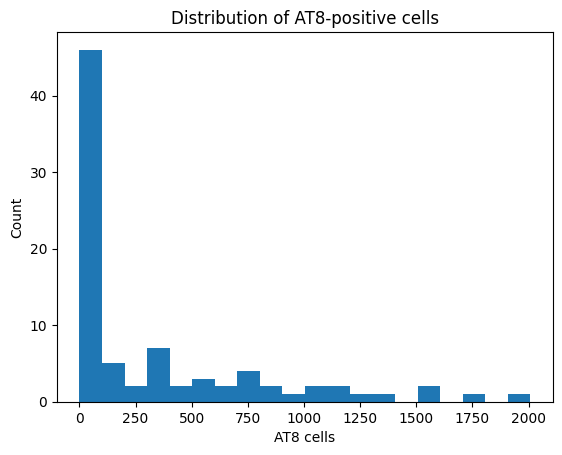

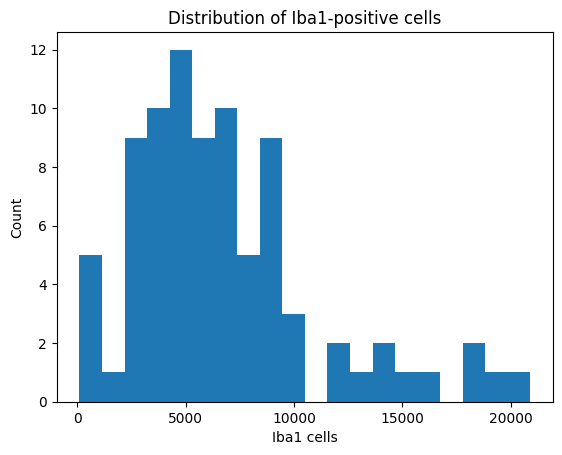

In [22]:
#plot dist of dependent variables
print("AT8 skew test:", skewtest(APOE4STATUS["AT8"]))
print("Iba1 skew test:", skewtest(APOE4STATUS["Iba1"]))

plt.figure()
plt.hist(APOE4STATUS["AT8"], bins=20)
plt.title("Distribution of AT8-positive cells")
plt.xlabel("AT8 cells")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(APOE4STATUS["Iba1"], bins=20)
plt.title("Distribution of Iba1-positive cells")
plt.xlabel("Iba1 cells")
plt.ylabel("Count")
plt.show()

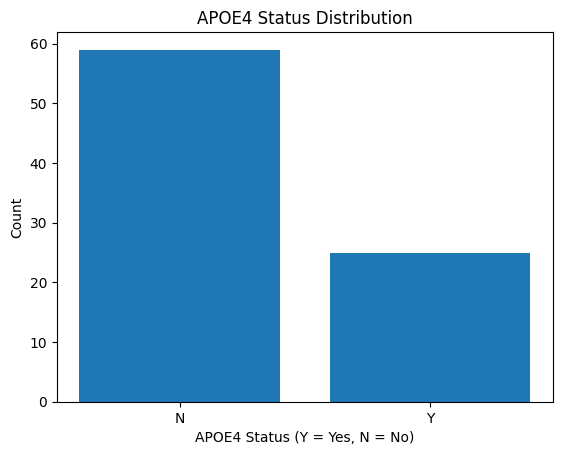

In [23]:
#plot dist of grouping variable(APOE4 status)

counts = APOE4STATUS["APOE4"].value_counts()

plt.figure()
plt.bar(counts.index, counts.values)
plt.title("APOE4 Status Distribution")
plt.xlabel("APOE4 Status (Y = Yes, N = No)")
plt.ylabel("Count")
plt.show()

Spearman (N): 0.08736987564212159 p = 0.5105369430103677
Spearman (Y): 0.05963832684621864 p = 0.7770409305876569


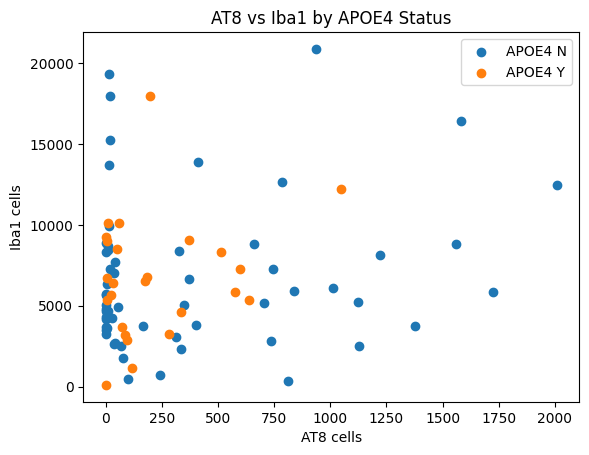

In [24]:
#corr coefficient scatterplot of relationship between each DV, color coded
rho_no, p_no = spearmanr(no["AT8"], no["Iba1"])
rho_yes, p_yes = spearmanr(yes["AT8"], yes["Iba1"])

print("Spearman (N):", rho_no, "p =", p_no)
print("Spearman (Y):", rho_yes, "p =", p_yes)


plt.figure()
plt.scatter(no["AT8"], no["Iba1"], label="APOE4 N")
plt.scatter(yes["AT8"], yes["Iba1"], label="APOE4 Y")

plt.title("AT8 vs Iba1 by APOE4 Status")
plt.xlabel("AT8 cells")
plt.ylabel("Iba1 cells")
plt.legend()
plt.show()

AT8 p-value: 0.9337004483620569
Iba1 p-value: 0.42241981495579106


/tmp/ipykernel_13835/4203344812.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no["AT8"], yes["AT8"]], labels=["N", "Y"])


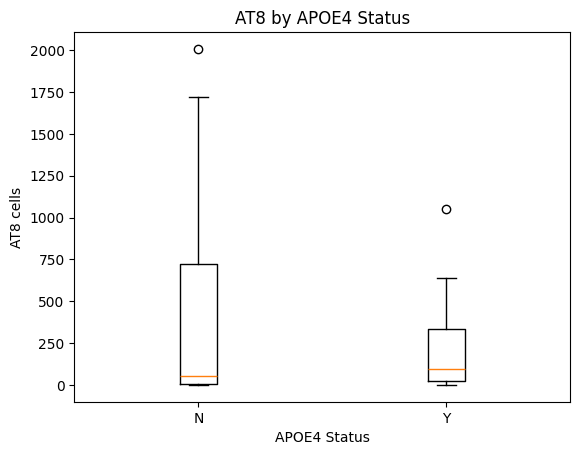

/tmp/ipykernel_13835/4203344812.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([no["Iba1"], yes["Iba1"]], labels=["N", "Y"])


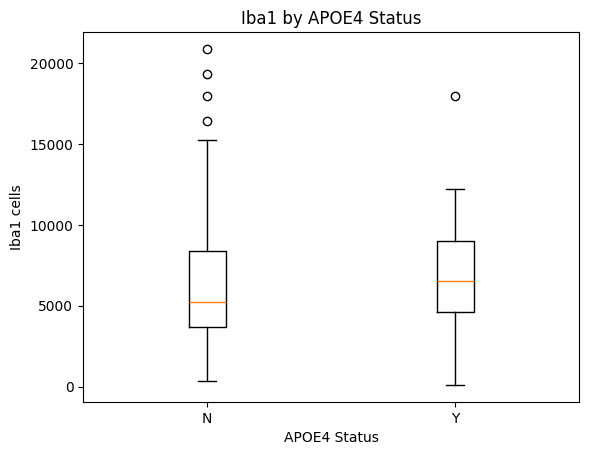

In [25]:
#stat tests, boxplots, how each DV varies by grouping variable
u_at8, p_at8 = mannwhitneyu(no["AT8"], yes["AT8"], alternative='two-sided')
print("AT8 p-value:", p_at8)
u_iba1, p_iba1 = mannwhitneyu(no["Iba1"], yes["Iba1"], alternative='two-sided')
print("Iba1 p-value:", p_iba1)


# AT8
plt.figure()
plt.boxplot([no["AT8"], yes["AT8"]], labels=["N", "Y"])
plt.title("AT8 by APOE4 Status")
plt.xlabel("APOE4 Status")
plt.ylabel("AT8 cells")
plt.show()

# IBA1
plt.figure()
plt.boxplot([no["Iba1"], yes["Iba1"]], labels=["N", "Y"])
plt.title("Iba1 by APOE4 Status")
plt.xlabel("APOE4 Status")
plt.ylabel("Iba1 cells")
plt.show()